### Аналитическое решение линейной регрессии:
$$ y=Xw+ε $$
где y - target
    X - матрица признаков
    w - вектор весов модели
    ε - вектор ошибок. 
Отсюда:  
$$ ε=y-Xw $$
На основе этого эпсилан мы строим функцию потерь:
$$ L(w) = ||ε||^2 = ||y-Xw||^2 = (y-Xw)^T(y-Xw) $$
Мы имеем функцию сумму квадратов ошибок, получается, что, чем меньше эта функция, тем лучше наша модель спрогназировала таргеты.  
Отсюда, мы хотим минимизировать нашу функцию, для этого нам надо взять антиградиент функции:  
$$ L(w)=y^Ty-2w^TX^Ty+w^TX^TXw $$
Берем градиент функции:
$$ ∇~w~L(w)=-2X^Ty+2X^TXw $$
Находим минимум функции:  
$$ ∇L(w)=0 $$
$$ -2X^Ty+2X^TXw=0 $$
$$ X^TXw=X^Ty $$
Отсюда получается, что:
$$ w=(X^TX)^{-1}X^Ty $$

### Линейная регрессия

Модель линейной регрессии предсказывает целевую переменную по формуле:

$$
\hat{y} = Xw + b
$$

где:
- $X$ — матрица признаков,
- $w$ — вектор весов модели,
- $b$ — смещение (bias),
- $\hat{y}$ — предсказанное значение целевой переменной.

Стандартная задача линейной регрессии — минимизировать сумму квадратов ошибок:

$$
\mathcal{L}(w, b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

### L2-регуляризация (Ridge)

L2-регуляризация добавляет штраф за большие значения весов:

$$
\mathcal{L}(w, b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{m} w_j^2
$$

Такой штраф не позволяет коэффициентам становиться слишком большими, благодаря чему модель обычно становится более устойчивой и лучше обобщается на новых данных.

### L1-регуляризация (Lasso)

L1-регуляризация использует сумму модулей весов:

$$
\mathcal{L}(w, b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{m} |w_j|
$$

В отличие от L2-регуляризации, L1-регуляризация может занулять некоторые веса полностью.  
Это делает её полезной не только для борьбы с переобучением, но и для отбора наиболее важных признаков.

### Elastic Net

Elastic Net объединяет L1 и L2 регуляризацию:

$$
\mathcal{L}(w, b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda_1 \sum_{j=1}^{m} |w_j| + \lambda_2 \sum_{j=1}^{m} w_j^2
$$

Такой подход полезен, когда хочется одновременно получить и уменьшение весов, и разреженное решение.

### Зачем нужна регуляризация

Если модель слишком гибкая, она может подстроиться не только под полезную закономерность в данных, но и под случайный шум.  
Это приводит к **переобучению**: модель хорошо работает на обучающей выборке, но хуже — на новых данных.

Регуляризация помогает:
- уменьшить сложность модели,
- ограничить рост слишком больших коэффициентов,
- сделать обучение более устойчивым,
- улучшить качество обобщения на тестовых данных.

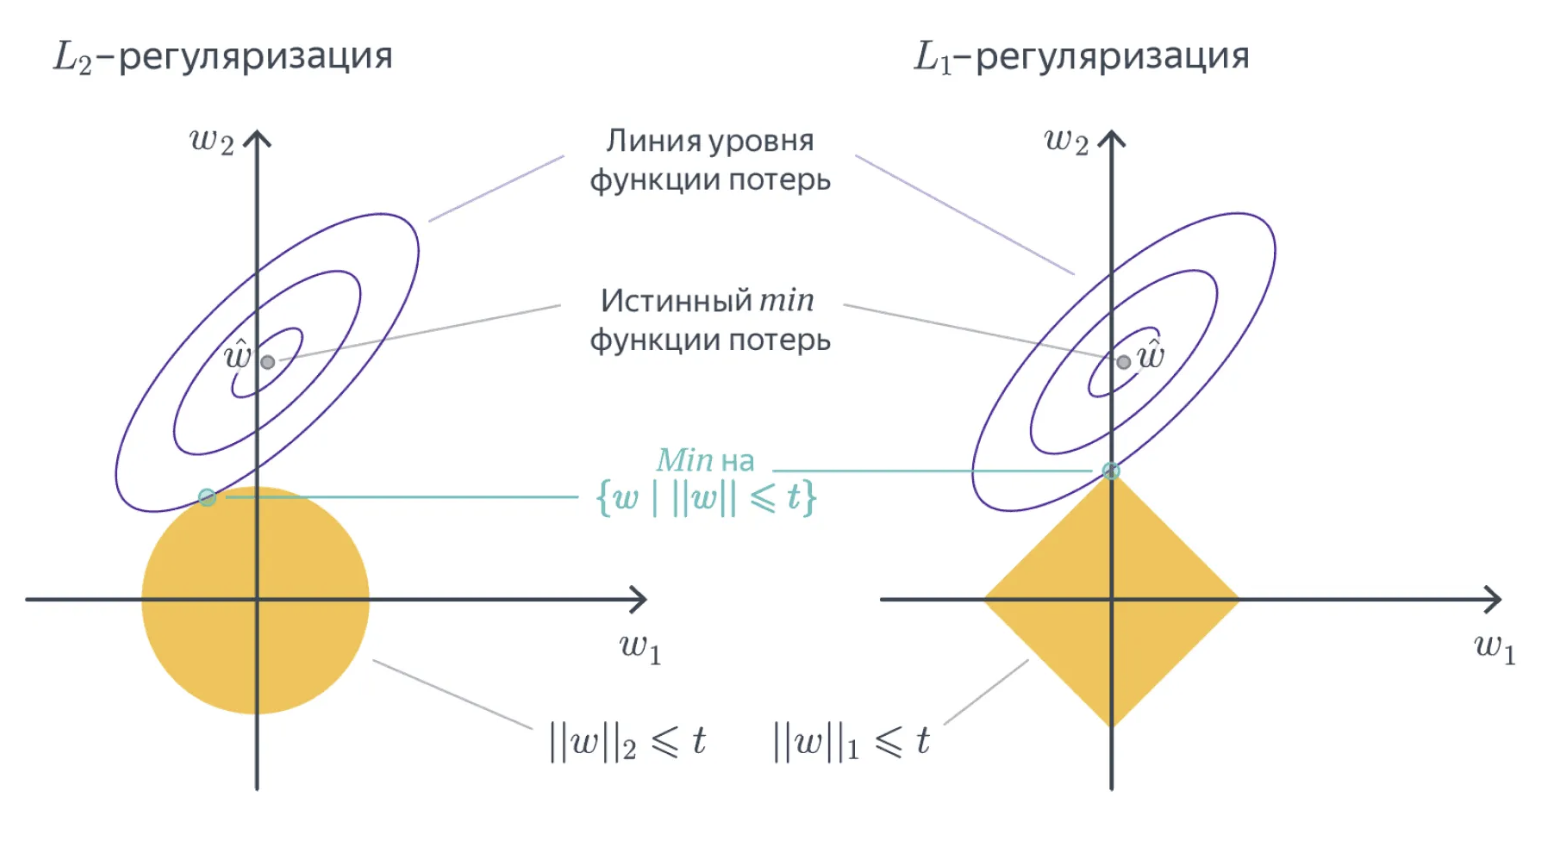

Также линейные модели могут моделировать нелинейные зависимости, но каким образом? Линейная модель определяется весами. Как пример, мы имеем модель: 
$$ y=w_{0}+w_1x+w_2x^2 $$
Она будет линейной, потому что мы пытаемся построить прямую по нашим весам. Даже если x будет нелинейным, то модель будет линейной, но зависимость уже будет нелинейной, так как в данном случае мы будем смотреть на наши признаки x.  
Линейные модели (регрессия, Ridge, Lasso) могут моделировать нелинейные зависимости — если преобразовать входные признаки с помощью нелинейных функций (полиномы, логарифмы, тригонометрия и т.д.). 

### Introduction ###

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error

In [3]:
train_df = pd.read_json('data/train.json')
test_df = pd.read_json('data/test.json')

In [4]:
train_df = train_df[(train_df["price"] > train_df["price"].quantile(0.01)) & (train_df["price"] < train_df["price"].quantile(0.99))]
test_df = test_df[(test_df["price"] >= train_df["price"].min()) & (test_df["price"] <= train_df["price"].max())]

In [5]:
train_df.head(2)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low


In [6]:
features_uniq=[]

for _,row in train_df.iterrows():
    features=row['features']
    for feature in features:
        if feature:
            features_uniq.append(feature.replace(' ',''))

print(len(set(features_uniq)))
features_uniq = Counter(features_uniq)
top_20_features = features_uniq.most_common(20)
top_20_features

1531


[('Elevator', 25375),
 ('HardwoodFloors', 23146),
 ('CatsAllowed', 23135),
 ('DogsAllowed', 21652),
 ('Doorman', 20479),
 ('Dishwasher', 20081),
 ('NoFee', 17793),
 ('LaundryinBuilding', 16082),
 ('FitnessCenter', 12989),
 ('Pre-War', 8971),
 ('LaundryinUnit', 8437),
 ('RoofDeck', 6417),
 ('OutdoorSpace', 5132),
 ('DiningRoom', 4890),
 ('HighSpeedInternet', 4223),
 ('Balcony', 2898),
 ('SwimmingPool', 2643),
 ('LaundryInBuilding', 2564),
 ('NewConstruction', 2504),
 ('Terrace', 2177)]

In [ ]:
features_list = []

for feature in top_20_features:
    features_list.append(feature[0])

In [ ]:
def clean_feature(s):
    return s.strip().replace(' ', '')

train_df['features'] = train_df['features'].apply(
    lambda lst: [clean_feature(item) for item in lst]
)
for feature in features_list:
    train_df[feature] = train_df['features'].apply(lambda x: 1 if feature in x else 0)


test_df['features'] = test_df['features'].apply(
    lambda lst: [clean_feature(item) for item in lst]
)
for feature in features_list:
    test_df[feature] = test_df['features'].apply(lambda x: 1 if feature in x else 0)
test_df.head(5)


train_df.head(5)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[DiningRoom, Pre-War, LaundryinBuilding, Dishw...",40.7108,7170325,-73.9539,...,0,0,0,1,0,0,0,0,0,0
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, LaundryinBuilding, Dishwas...",40.7513,7092344,-73.9722,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, LaundryinBuilding, Laundry...",40.7575,7158677,-73.9625,...,1,0,0,0,0,0,0,0,0,0
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, FitnessCenter, LaundryinBu...",40.7439,7225292,-73.9743,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
features_list.append('bathrooms')
features_list.append('bedrooms')

#### Models implementation — Linear regression ####

In [1106]:
class my_linear_regr():
    def __init__(self,learn_rate = 0.00001,n_epochs=100000,random_state=None):
        self.learn_rate = learn_rate
        self.n_epochs = n_epochs
        self.random_state = random_state

    def linear_model(self,w,x):
        return x @ w

    def derivative_square_error(self, w, x, y):
        prediction = self.linear_model(w, x)
        return -2 * (y - prediction) * x

    def fit(self,X_train,y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        X = np.c_[np.ones(X.shape[0]),X]
        # Инициализируем веса
        w = np.zeros(X.shape[1])

        if self.random_state is not None:
            np.random.seed(self.random_state)

        n_samples = X.shape[0]

        for _ in range(self.n_epochs):
            idx = np.random.randint(0, n_samples)
            grad = self.derivative_square_error(w, X[idx], y[idx])
            w = w - self.learn_rate * grad
        self.w = w
        return self
    
    def predict(self, X_train):
        X = np.array(X_train)
        X = np.c_[np.ones(X.shape[0]), X]
        return self.linear_model(self.w, X)

In [1107]:
class my_linear_regr_analytic:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).flatten()
        X_b = np.c_[np.ones(X.shape[0]), X]
        self.w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        
        return self

    def predict(self, X):
        X = np.array(X)
        X_b = np.c_[np.ones(X.shape[0]), X]
        return X_b @ self.w

In [ ]:
models = ['MyLinreg','Linreg','MyRidge', 'Ridge', 'MyLasso', 'Lasso', 
          'MyElasticNet', 'ElasticNet','LinReg_MinMax','sk_LinReg_MinMax',
          'Ridge_MinMax','sk_Ridge_MinMax','Lasso_MinMax','sk_Lasso_MinMax',
          'ElasticNet_MinMax','sk_ElasticNet_MinMax','LinReg_Standart',
          'Ridge_Standart','Lasso_Standart','ElasticNet_Standart',
          'sk_LinReg_Standart','sk_Ridge_Standart','sk_Lasso_Standart',
          'sk_ElasticNet_Standart','overfit_Linreg','overfit_Ridge',
          'overfit_Lasso','overfit_ElasticNet']

df_mae = pd.DataFrame(index=models, columns=['Train', 'Test'])
df_rmse = pd.DataFrame(index=models, columns=['Train', 'Test'])
df_r2 = pd.DataFrame(index=models, columns=['Train', 'Test'])

In [18]:
def evaluate_and_store(model, model_name, X_train, X_test, y_train, y_test, 
                      df_mae, df_rmse, df_r2, get_metrics):
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)

    df_mae.loc[model_name, 'Train'] = train_metrics['MAE']
    df_mae.loc[model_name, 'Test'] = test_metrics['MAE']
    
    df_rmse.loc[model_name, 'Train'] = train_metrics['RMSE']
    df_rmse.loc[model_name, 'Test'] = test_metrics['RMSE']
    
    df_r2.loc[model_name, 'Train'] = train_metrics['R2']
    df_r2.loc[model_name, 'Test'] = test_metrics['R2']

In [13]:
def r2(y_true,y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    if np.any(np.isnan(y_pred)) or np.any(np.isinf(y_pred)):
        return {'MAE': np.nan, 'RMSE': np.nan, 'R2': np.nan}

    y_mean = np.mean(y_true)

    ss_pred = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_mean)**2)

    r2 = 1 - ss_pred/ss_tot
    return r2

In [15]:
train_df = train_df[features_list+['price']]
test_df = test_df[features_list+['price']]

X_train = train_df[features_list]
X_test = test_df[features_list]

y_train = train_df['price']
y_test = test_df['price']

In [16]:
def get_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mae = np.mean(np.abs(y_true - y_pred))
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

In [1114]:
my_model = my_linear_regr(learn_rate = 0.00001,n_epochs=100000,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='MyLinreg',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)


In [1115]:
model_sk = LinearRegression()
evaluate_and_store(
    model=model_sk,
    model_name='Linreg',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)


In [1116]:
df_mae

,Train,Test
MyLinreg,774.0982,775.2845
Linreg,708.7371,713.0101
MyRidge,NaN,NaN
Ridge,NaN,NaN
MyLasso,NaN,NaN
Lasso,NaN,NaN
MyElasticNet,NaN,NaN
ElasticNet,NaN,NaN
LinReg_MinMax,NaN,NaN
sk_LinReg_MinMax,NaN,NaN


### Regularized models implementation — Ridge, Lasso, ElasticNet ###

In [1117]:
class MyRidge:
    def __init__(self,learn_rate = 0.0001,n_epochs=500000,random_state=None,alpha = 0.001):
        self.learn_rate = learn_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.alpha = alpha

    def linear_model(self,w,x):
        return x @ w

    def derivative_square_error(self, w, x, y):
        prediction = self.linear_model(w, x)
        grad = -2 * (y - prediction) * x
        grad[1:] += 2 * self.alpha * w[1:]
        return grad

    def fit(self,X_train,y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        X = np.c_[np.ones(X.shape[0]),X]
        # Инициализируем веса
        w = np.zeros(X.shape[1])

        if self.random_state is not None:
            np.random.seed(self.random_state)

        n_samples = X.shape[0]

        for _ in range(self.n_epochs):
            idx = np.random.randint(0, n_samples)
            grad = self.derivative_square_error(w, X[idx], y[idx])
            w = w - self.learn_rate * grad
        self.w = w
        return self
    
    def predict(self, X_train):
        X = np.array(X_train)
        X = np.c_[np.ones(X.shape[0]), X]
        return self.linear_model(self.w, X)

In [1118]:
class MyLasso:
    def __init__(self,learn_rate = 0.0001,n_epochs=500000,random_state=None,alpha = 0.001):
        self.learn_rate = learn_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.alpha = alpha

    def linear_model(self,w,x):
        return x @ w

    def derivative_square_error(self, w, x, y):
        prediction = self.linear_model(w, x)
        grad = -2 * (y - prediction) * x
        grad[1:] += self.alpha * np.sign(w[1:])
        return grad

    def fit(self,X_train,y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        X = np.c_[np.ones(X.shape[0]),X]
        # Инициализируем веса
        w = np.zeros(X.shape[1])

        if self.random_state is not None:
            np.random.seed(self.random_state)

        n_samples = X.shape[0]

        for _ in range(self.n_epochs):
            idx = np.random.randint(0, n_samples)
            grad = self.derivative_square_error(w, X[idx], y[idx])
            w = w - self.learn_rate * grad
        self.w = w
        return self
    
    def predict(self, X_train):
        X = np.array(X_train)
        X = np.c_[np.ones(X.shape[0]), X]
        return self.linear_model(self.w, X)

In [1119]:
class MyElasticnet:
    def __init__(self,learn_rate = 0.0001,n_epochs=500000,alpha=0.001,l1_ratio = 0.5,random_state=None):
        self.learn_rate = learn_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.alpha = alpha
        self.l1_ratio = l1_ratio

    def linear_model(self,w,x):
        return x @ w

    def derivative_square_error(self, w, x, y):
        prediction = self.linear_model(w, x)
        grad = -2 * (y - prediction) * x
        l1 = self.l1_ratio * np.sign(w[1:])
        l2 = 2*(1 - self.l1_ratio)*w[1:]
        grad[1:] += self.alpha * (l1+l2)
        return grad

    def fit(self,X_train,y_train):
        X = np.array(X_train)
        y = np.array(y_train).flatten()

        X = np.c_[np.ones(X.shape[0]),X]
        # Инициализируем веса
        w = np.zeros(X.shape[1])

        if self.random_state is not None:
            np.random.seed(self.random_state)

        n_samples = X.shape[0]

        for _ in range(self.n_epochs):
            idx = np.random.randint(0, n_samples)
            grad = self.derivative_square_error(w, X[idx], y[idx])
            w = w - self.learn_rate * grad
        self.w = w
        return self
    
    def predict(self, X_train):
        X = np.array(X_train)
        X = np.c_[np.ones(X.shape[0]), X]
        return self.linear_model(self.w, X)

In [1120]:
my_model = MyRidge(learn_rate=0.00001, n_epochs=100000, random_state=21, alpha=0.001)
evaluate_and_store(
    model=my_model,
    model_name='MyRidge',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)


In [1121]:
sk_ridge = Ridge(alpha=0.001, random_state=21)
evaluate_and_store(
    model=sk_ridge,
    model_name='Ridge',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1122]:
df_mae

,Train,Test
MyLinreg,774.0982,775.2845
Linreg,708.7371,713.0101
MyRidge,774.0738,775.2579
Ridge,708.7371,713.0101
MyLasso,NaN,NaN
Lasso,NaN,NaN
MyElasticNet,NaN,NaN
ElasticNet,NaN,NaN
LinReg_MinMax,NaN,NaN
sk_LinReg_MinMax,NaN,NaN


In [1123]:
my_model = MyLasso(learn_rate=0.00001, n_epochs=100000, random_state=21, alpha=0.001)
evaluate_and_store(
    model=my_model,
    model_name='MyLasso',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)


In [ ]:
my_model = Lasso(alpha=0.001, random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='Lasso',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)


In [1125]:
my_model = MyElasticnet(learn_rate = 0.00001,n_epochs=100000,alpha=0.001,l1_ratio = 0.5,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='MyElasticNet',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1126]:
my_model = ElasticNet(alpha=0.001,l1_ratio = 0.5,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='ElasticNet',
    X_train=X_train, X_test=X_test,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1127]:
df_r2

,Train,Test
MyLinreg,0.5084,0.4435
Linreg,0.5803,0.4052
MyRidge,0.5083,0.4435
Ridge,0.5803,0.4052
MyLasso,0.5084,0.4435
Lasso,0.5803,0.4052
MyElasticNet,0.5084,0.4435
ElasticNet,0.5803,0.4062
LinReg_MinMax,NaN,NaN
sk_LinReg_MinMax,NaN,NaN


### Feature normalization ###

Теперь поговорим про нормализацию признаков.  
  

Бывает такое, что некоторые признаки бывают огромными на фоне других признаков, вследствие чего модель начинает неправильно обучаться. Благодаря такому признаку, модель начинает обращать внимание только на него, то есть большой признак "стягивает" модель. Модель думает, что раз признак самый большой, значит он полезный, но на самом деле это не всегда так. Поэтому как раз тут и приходит на помощь нормализация, которая делает все признаки в одном масштабе.  
  

Но всегда ли полезна эта нормализация? Давайте подумаем

В определенных алгоритмах, __основанных на расстоянии__, таких как k-nn, svm, k-means, нормализация чрезвычайно важна, ввиду алгоритма решений, основанных на расстояниях между точками.  
Помимо этого, нормализация часто нужна при регуляризации. При больших весах, наша регуляризация сильно штрафует её, ввиду этого получается очень маленький признак.

А вот уже для таких алгоритмов, как: деревья решений, XGBoost и др - нормализация не нужна. В этих случаях, алгоритм их решений строится не на расстоянии или на градиенте.  
В их число также можно закинуть и категориальные признаки. В этом случае у нас происходит кодировка признаков. Как пример, цвета. 



Чтобы сделать нормализацию данных нужно посчитать в каждом признаке его минимум и максимум, а затем сделать вычисление:  
$$ x=\frac{x-min}{max-min} $$
После этого, все признаки будут находиться в отрезке от 0 до 1

In [1128]:
mins = X_train.min()
maxs = X_train.max()

display(mins, maxs)

Elevator            0.0000
HardwoodFloors      0.0000
CatsAllowed         0.0000
DogsAllowed         0.0000
Doorman             0.0000
Dishwasher          0.0000
NoFee               0.0000
LaundryinBuilding   0.0000
FitnessCenter       0.0000
Pre-War             0.0000
LaundryinUnit       0.0000
RoofDeck            0.0000
OutdoorSpace        0.0000
DiningRoom          0.0000
HighSpeedInternet   0.0000
Balcony             0.0000
SwimmingPool        0.0000
LaundryInBuilding   0.0000
NewConstruction     0.0000
Terrace             0.0000
bathrooms           0.0000
bedrooms            0.0000
dtype: float64

Elevator             1.0000
HardwoodFloors       1.0000
CatsAllowed          1.0000
DogsAllowed          1.0000
Doorman              1.0000
Dishwasher           1.0000
NoFee                1.0000
LaundryinBuilding    1.0000
FitnessCenter        1.0000
Pre-War              1.0000
LaundryinUnit        1.0000
RoofDeck             1.0000
OutdoorSpace         1.0000
DiningRoom           1.0000
HighSpeedInternet    1.0000
Balcony              1.0000
SwimmingPool         1.0000
LaundryInBuilding    1.0000
NewConstruction      1.0000
Terrace              1.0000
bathrooms           10.0000
bedrooms             8.0000
dtype: float64

In [ ]:
def myMinMaxScaler(X: pd.DataFrame) -> pd.DataFrame:
    X_scaled = X.copy()
    
    X_scaled = (X_scaled - X.min()) / (X.max() - X.min())

    return X_scaled

In [1130]:
class MyMinMaxScaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None
        self.range_ = None

    def fit(self, X):
        X = pd.DataFrame(X)
        self.min_ = X.min()
        self.max_ = X.max()
        self.range_ = self.max_ - self.min_
        self.range_ = self.range_.replace(0, 1)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_scaled = (X - self.min_) / self.range_
        X_scaled = X_scaled.fillna(0)
        return X_scaled

    def fit_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return self.fit(X).transform(X)

In [1131]:
my_scaler = MyMinMaxScaler()
X_train_scaled = my_scaler.fit_transform(X_train)
X_train_scaled.head(3)

,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,...,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,bathrooms,bedrooms
4,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,...,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1000,0.1250
6,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1000,0.2500
9,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1000,0.2500


In [ ]:
minMaxScaler = MinMaxScaler()
X_train_scaler = minMaxScaler.fit_transform(X_train)

Теперь поговорим про такой метод масштабирования, как __Стандартизация__. 
Здесь будешь меньше текста, потому что введение я написал в нормализации.  
Формула стандартизации выглядит следующим образом:
$$ x=\frac{x-mean}{std} $$
После такого преобразования у признаков mean=0,std=1

In [1133]:
class MyStandart:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        X = pd.DataFrame(X)
        self.mean_ = X.mean()
        self.std_ = X.std()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_scaled = (X - self.mean_) / self.std_
        return X_scaled

    def fit_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return self.fit(X).transform(X)

In [1134]:
pd.set_option('display.float_format', lambda x: '%0.4f' % x)

In [1135]:
my_standart = MyStandart()
X_train_mystandart = my_standart.fit_transform(X_train)
X_train_mystandart.head(5)

,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,FitnessCenter,Pre-War,...,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,bathrooms,bedrooms
4,-1.0511,1.0434,1.0438,1.1103,-0.8573,1.1863,-0.7632,1.4163,-0.6061,2.0949,...,-0.3446,2.9809,-0.3094,-0.2525,-0.2405,-0.2367,-0.2337,-0.2172,-0.4273,-0.4851
6,0.9514,1.0434,-0.9580,-0.9007,1.1664,1.1863,1.3103,1.4163,-0.6061,-0.4773,...,-0.3446,-0.3355,-0.3094,-0.2525,-0.2405,-0.2367,-0.2337,-0.2172,-0.4273,0.4230
9,0.9514,1.0434,-0.9580,-0.9007,1.1664,1.1863,-0.7632,1.4163,-0.6061,-0.4773,...,-0.3446,-0.3355,-0.3094,-0.2525,-0.2405,-0.2367,-0.2337,-0.2172,-0.4273,0.4230
10,-1.0511,-0.9584,-0.9580,-0.9007,-0.8573,-0.8429,-0.7632,-0.7060,-0.6061,-0.4773,...,-0.3446,-0.3355,-0.3094,-0.2525,-0.2405,-0.2367,-0.2337,-0.2172,0.6703,1.3310
15,0.9514,-0.9584,-0.9580,-0.9007,1.1664,-0.8429,-0.7632,1.4163,1.6498,-0.4773,...,-0.3446,-0.3355,-0.3094,-0.2525,-0.2405,-0.2367,-0.2337,-0.2172,-0.4273,-1.3931


In [ ]:
standartcs = StandardScaler()
X_train_standart = standartcs.fit_transform(X_train)

In [1137]:
my_model = my_linear_regr(learn_rate = 0.01,n_epochs=200000,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='LinReg_MinMax',
    X_train=X_train_scaled, X_test=my_scaler.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1138]:
my_model = my_linear_regr(learn_rate = 0.0001,n_epochs=200000,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='LinReg_Standart',
    X_train=X_train_mystandart, X_test=my_standart.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1139]:
model_sk = LinearRegression()
evaluate_and_store(
    model=model_sk,
    model_name='sk_LinReg_MinMax',
    X_train=X_train_scaled, X_test=my_scaler.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)
evaluate_and_store(
    model=model_sk,
    model_name='sk_LinReg_Standart',
    X_train=X_train_mystandart, X_test=my_standart.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1140]:
my_model = MyRidge(learn_rate=0.01, n_epochs=200000, random_state=21, alpha=0.001)
evaluate_and_store(
    model=my_model,
    model_name='Ridge_MinMax',
    X_train=X_train_scaled, X_test=my_scaler.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1141]:
my_model = MyRidge(learn_rate=0.0001, n_epochs=200000, random_state=21, alpha=0.001)
evaluate_and_store(
    model=my_model,
    model_name='Ridge_Standart',
    X_train=X_train_mystandart, X_test=my_standart.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1142]:
model_sk = Ridge(alpha=0.001, random_state=21)
evaluate_and_store(
    model=model_sk,
    model_name='sk_Ridge_MinMax',
    X_train=X_train_scaled, X_test=my_scaler.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)
evaluate_and_store(
    model=model_sk,
    model_name='sk_Ridge_Standart',
    X_train=X_train_mystandart, X_test=my_standart.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1143]:
my_model = MyLasso(learn_rate=0.01, n_epochs=200000, random_state=21, alpha=0.001)
evaluate_and_store(
    model=my_model,
    model_name='Lasso_MinMax',
    X_train=X_train_scaled, X_test=my_scaler.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1144]:
my_model = MyLasso(learn_rate=0.0001, n_epochs=200000, random_state=21, alpha=0.001)
evaluate_and_store(
    model=my_model,
    model_name='Lasso_Standart',
    X_train=X_train_mystandart, X_test=my_standart.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1145]:
model_sk = Lasso(alpha=0.001, random_state=21)
evaluate_and_store(
    model=model_sk,
    model_name='sk_Lasso_MinMax',
    X_train=X_train_scaled, X_test=my_scaler.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)
evaluate_and_store(
    model=model_sk,
    model_name='sk_Lasso_Standart',
    X_train=X_train_mystandart, X_test=my_standart.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1146]:
my_model = MyElasticnet(learn_rate = 0.01,n_epochs=200000,alpha=0.001,l1_ratio = 0.5,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='ElasticNet_MinMax',
    X_train=X_train_scaled, X_test=my_scaler.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1147]:
my_model = MyElasticnet(learn_rate = 0.0001,n_epochs=200000,alpha=0.001,l1_ratio = 0.5,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='ElasticNet_Standart',
    X_train=X_train_mystandart, X_test=my_standart.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1148]:
sk_model = ElasticNet(alpha=0.001,l1_ratio = 0.5,random_state=21)
evaluate_and_store(
    model=sk_model,
    model_name='sk_ElasticNet_MinMax',
    X_train=X_train_scaled, X_test=my_scaler.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)
evaluate_and_store(
    model=sk_model,
    model_name='sk_ElasticNet_Standart',
    X_train=X_train_mystandart, X_test=my_standart.transform(X_test),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1149]:
df_r2

,Train,Test
MyLinreg,0.5084,0.4435
Linreg,0.5803,0.4052
MyRidge,0.5083,0.4435
Ridge,0.5803,0.4052
MyLasso,0.5084,0.4435
Lasso,0.5803,0.4052
MyElasticNet,0.5084,0.4435
ElasticNet,0.5803,0.4062
LinReg_MinMax,0.5598,0.3818
sk_LinReg_MinMax,0.5803,0.4052


In [1150]:
df_mae

,Train,Test
MyLinreg,774.0982,775.2845
Linreg,708.7371,713.0101
MyRidge,774.0738,775.2579
Ridge,708.7371,713.0101
MyLasso,774.0980,775.2843
Lasso,708.7365,713.0095
MyElasticNet,774.0859,775.2711
ElasticNet,708.6692,712.9233
LinReg_MinMax,739.0101,743.8378
sk_LinReg_MinMax,708.7371,713.0101


#### Overfit models ####

In [1151]:
X_train_poly_2f = X_train[['bathrooms','bedrooms']]
X_test_poly_2f = X_test[['bathrooms','bedrooms']]

In [1152]:
poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train_poly_2f)
X_test_poly = poly.transform(X_test_poly_2f)

In [1154]:
standart = StandardScaler()
X_train_poly = standart.fit_transform(X_train_poly)
X_test_poly = standart.transform(X_test_poly)

In [1155]:
my_model = my_linear_regr(learn_rate=0.000001,n_epochs=5000000,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='overfit_Linreg',
    X_train=X_train_poly, X_test=X_test_poly,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)


In [ ]:
my_model = MyRidge(learn_rate=0.000001, n_epochs=1000000, random_state=21, alpha=0.001)
evaluate_and_store(
    model=my_model,
    model_name='overfit_Ridge',
    X_train=X_train_poly, X_test=X_test_poly,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1157]:
my_model = MyLasso(learn_rate=0.000001, n_epochs=1000000, random_state=21, alpha=0.001)
evaluate_and_store(
    model=my_model,
    model_name='overfit_Lasso',
    X_train=X_train_poly, X_test=X_test_poly,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1158]:
my_model = MyElasticnet(learn_rate = 0.000001,n_epochs=1000000,alpha=0.001,l1_ratio = 0.5,random_state=21)
evaluate_and_store(
    model=my_model,
    model_name='overfit_ElasticNet',
    X_train=X_train_poly, X_test=X_test_poly,
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

#### Naive models ####

In [1159]:
y_train_mean = y_train.mean()
y_test_mean = y_test.mean()

y_train_median = y_train.median()
y_test_median = y_test.median()

In [1160]:
def add_naive_model(name, y_pred_train, y_pred_test, y_train, y_test, df_mae, df_rmse, df_r2, get_metrics):
    train_metrics = get_metrics(y_train, y_pred_train)
    test_metrics  = get_metrics(y_test,  y_pred_test)
    
    df_mae.loc[name, 'Train'] = train_metrics['MAE']
    df_mae.loc[name, 'Test']  = test_metrics['MAE']
    
    df_rmse.loc[name, 'Train'] = train_metrics['RMSE']
    df_rmse.loc[name, 'Test']  = test_metrics['RMSE']
    
    df_r2.loc[name, 'Train'] = train_metrics['R2']
    df_r2.loc[name, 'Test']  = test_metrics['R2']

In [1161]:
y_mean = y_train.mean()
add_naive_model(
    name='Naive_Mean',
    y_pred_train=np.full_like(y_train, y_mean),
    y_pred_test=np.full_like(y_test, y_mean),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

y_mediana = y_train.median()
add_naive_model(
    name='Naive_Median',
    y_pred_train=np.full_like(y_train, y_mediana),
    y_pred_test=np.full_like(y_test, y_mediana),
    y_train=y_train, y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1162]:
df_r2

,Train,Test
MyLinreg,0.5084,0.4435
Linreg,0.5803,0.4052
MyRidge,0.5083,0.4435
Ridge,0.5803,0.4052
MyLasso,0.5084,0.4435
Lasso,0.5803,0.4052
MyElasticNet,0.5084,0.4435
ElasticNet,0.5803,0.4062
LinReg_MinMax,0.5598,0.3818
sk_LinReg_MinMax,0.5803,0.4052


In [1163]:
df_mae

,Train,Test
MyLinreg,774.0982,775.2845
Linreg,708.7371,713.0101
MyRidge,774.0738,775.2579
Ridge,708.7371,713.0101
MyLasso,774.0980,775.2843
Lasso,708.7365,713.0095
MyElasticNet,774.0859,775.2711
ElasticNet,708.6692,712.9233
LinReg_MinMax,739.0101,743.8378
sk_LinReg_MinMax,708.7371,713.0101


In [1164]:
df_rmse

,Train,Test
MyLinreg,1111.7517,1173.8800
Linreg,1027.2629,1213.5985
MyRidge,1111.8034,1173.8464
Ridge,1027.2629,1213.5985
MyLasso,1111.7515,1173.8798
Lasso,1027.2629,1213.5982
MyElasticNet,1111.7774,1173.8631
ElasticNet,1027.2659,1212.5901
LinReg_MinMax,1052.0011,1237.2060
sk_LinReg_MinMax,1027.2629,1213.5985


Глядя на оба датафрейма, можно выделить 2 модельки: __Ridge_MinMax__,__sk_ElasticNet_MinMax__.   
В принципе, у обоих моделек почти одинаковые метрики, но все-таки вторая модель показывает себя лучше.   
Поэтому лучшая модель - это __sk_ElasticNet_MinMax__ 

Со стабильной моделькой чуть все сложнее. Для выявления стабильной модельки нам нужна валидация и новые данные.  
На наших данных моделях сложно оценить, что является стабильной, но я считаю, что стабильной моделькой в нашем случае можно считать Ridge_MinMax

#### BONUS ####

In [1182]:
def evaluate_log_model(model, model_name, X_train, X_test, y_train, y_test,
                      df_mae, df_rmse, df_r2, get_metrics):
    y_train_log = np.log(y_train)
    y_test_log = np.log(y_test)
    
    model.fit(X_train, y_train_log)
    
    y_train_pred_log = model.predict(X_train)
    y_test_pred_log = model.predict(X_test)
    
    y_train_pred = np.exp(y_train_pred_log)
    y_test_pred = np.exp(y_test_pred_log)
    
    train_metrics = get_metrics(y_train, y_train_pred)
    test_metrics = get_metrics(y_test, y_test_pred)

    df_mae.loc[model_name, 'Train'] = train_metrics['MAE']
    df_mae.loc[model_name, 'Test'] = test_metrics['MAE']
    
    df_rmse.loc[model_name, 'Train'] = train_metrics['RMSE']
    df_rmse.loc[model_name, 'Test'] = test_metrics['RMSE']
    
    df_r2.loc[model_name, 'Train'] = train_metrics['R2']
    df_r2.loc[model_name, 'Test'] = test_metrics['R2']

In [1183]:
model = LinearRegression()
evaluate_log_model(
    model=model,
    model_name='LinReg_LogTarget',
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    df_mae=df_mae, df_rmse=df_rmse, df_r2=df_r2,
    get_metrics=get_metrics
)

In [1185]:
df_r2

,Train,Test
MyLinreg,0.5084,0.4435
Linreg,0.5803,0.4052
MyRidge,0.5083,0.4435
Ridge,0.5803,0.4052
MyLasso,0.5084,0.4435
Lasso,0.5803,0.4052
MyElasticNet,0.5084,0.4435
ElasticNet,0.5803,0.4062
LinReg_MinMax,0.5598,0.3818
sk_LinReg_MinMax,0.5803,0.4052
